# Experimento 04

## Aumentación 1: Time-shift

In [1]:
from framework.framework_final import Persister, MetricsCalculator, AudioResNetModel, GSC, Preprocessor, Trainer, Evaluator, prepare_batch, plot_curves, show_image_grid, signal_grad_cam_overlays2d
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import numpy as np
from typing import List, Dict, Any, Optional
import pandas as pd
from sklearn.preprocessing import LabelEncoder

from signal_grad_cam.pytorch_cam_builder import TorchCamBuilder

I0000 00:00:1780894995.174819    3081 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780894995.205772    3081 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780894996.024316    3081 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780894996.024572    3081 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
AUDIO_PATH = Path('/mnt/data/GSC/normalized-dataset')
XTRAIN_PATH = Path('./dataframes/FASE2-X_train.csv')
XTEST_PATH = Path('./dataframes/FASE2-X_test.csv')
XVAL_PATH = Path('./dataframes/FASE2-X_val.csv')
YVAL_PATH = Path('./dataframes/FASE2-y_val.csv')
YTRAIN_PATH = Path('./dataframes/FASE2-y_train.csv')
YTEST_PATH = Path('./dataframes/FASE2-y_test.csv')
BACKGROUND_NOISES = sorted(Path(f"/mnt/data/GSC/speech_commands_v0.02/_background_noise_/").glob('*wav'))

NUM_CLASSES = 35

DEVICE = 'cuda'

# Cambios MELs
SAMPLE_RATE = 16000
N_MELS =128
N_FFT = int(768)
WIN_LENGTH = N_FFT
HOP_LENGTH = int(100)

In [3]:
final_path = '04-experimento_04/final'
checkpoints_path = '04-experimento_04/checkpoints'
xai_path = Path('/mnt/data/GSC/XAI/04-experimento_04')
batch_size = 224
epochs = 10

In [4]:
%%capture 
# Instanciación del framework
persister = Persister(final_path=final_path, checkpoints_path=checkpoints_path, xai_path=xai_path)
preprocessor_train = Preprocessor(
        sample_rate = SAMPLE_RATE,
        n_mels = N_MELS,
        win_length = WIN_LENGTH,
        hop_length = HOP_LENGTH,
        n_fft = N_FFT,
        with_log = True,
        device = DEVICE,
        mode = "training",
        augmentation_probs = {"time_shift" : 0.5})

preprocessor_test = Preprocessor(
        sample_rate = SAMPLE_RATE,
        n_mels = N_MELS,
        win_length = WIN_LENGTH,
        hop_length = HOP_LENGTH,
        n_fft = N_FFT,    
        with_log = True,
        device = DEVICE)
# Modelo
model = AudioResNetModel(dims=2, num_classes=NUM_CLASSES).get_model()
model.to(DEVICE)

In [5]:
# Conjuntos de datos
X_train = pd.read_csv(XTRAIN_PATH)
X_test = pd.read_csv(XTEST_PATH)
y_train = pd.read_csv(YTRAIN_PATH)
y_test = pd.read_csv(YTRAIN_PATH)
X_val = pd.read_csv(XVAL_PATH)                                                                                                          
y_val = pd.read_csv(YVAL_PATH)                                                                                                          

le = LabelEncoder()

y_encoded = le.fit_transform(y_train['keyword'])
ytest_encoded = le.transform(y_test['keyword'])
yval_encoded = le.transform(y_val['keyword'])

label_names= le.classes_

train_list = X_train['path_normalized'].tolist()                                                                                            
train_labels = y_encoded.tolist() 
val_list = X_val['path_normalized'].tolist()                                                                                            
val_labels = yval_encoded.tolist() 
test_list = X_test['path_normalized'].tolist()
test_labels = ytest_encoded.tolist()

train_dataset = GSC(file_list=train_list, labels=train_labels)
validation_dataset = GSC(file_list=val_list, labels=val_labels)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=prepare_batch, num_workers=4)
val_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False, collate_fn=prepare_batch, num_workers=4)
test_dataset = GSC(test_list, test_labels)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False, collate_fn = prepare_batch, num_workers = 4)

In [6]:
trainer = Trainer(model=model, train_loader=train_loader, val_loader=val_loader, preprocessor=preprocessor_train, persister=persister, device=DEVICE, epochs=10)                        
trainer.fit(resume=False)

Epoch::   0%|          | 0/10 [00:00<?, ?it/s]

Batches entrenamiento:   0%|          | 0/331 [00:00<?, ?it/s]

Batches validación:   0%|          | 0/48 [00:00<?, ?it/s]

Epoch 1/10
  Train - Pérdida: 0.6488, Accuracy: 0.8154, F1-score: 0.8072
  Val   - Pérdida: 0.4730, Accuracy: 0.8571, F1-score: 0.8436


Batches entrenamiento:   0%|          | 0/331 [00:00<?, ?it/s]

...

Batches validación:   0%|          | 0/48 [00:00<?, ?it/s]

Epoch 9/10
  Train - Pérdida: 0.0757, Accuracy: 0.9762, F1-score: 0.9739
  Val   - Pérdida: 0.2677, Accuracy: 0.9287, F1-score: 0.9241


Batches entrenamiento:   0%|          | 0/331 [00:00<?, ?it/s]

Batches validación:   0%|          | 0/48 [00:00<?, ?it/s]

Epoch 10/10
  Train - Pérdida: 0.0715, Accuracy: 0.9779, F1-score: 0.9761
  Val   - Pérdida: 0.2393, Accuracy: 0.9355, F1-score: 0.9304


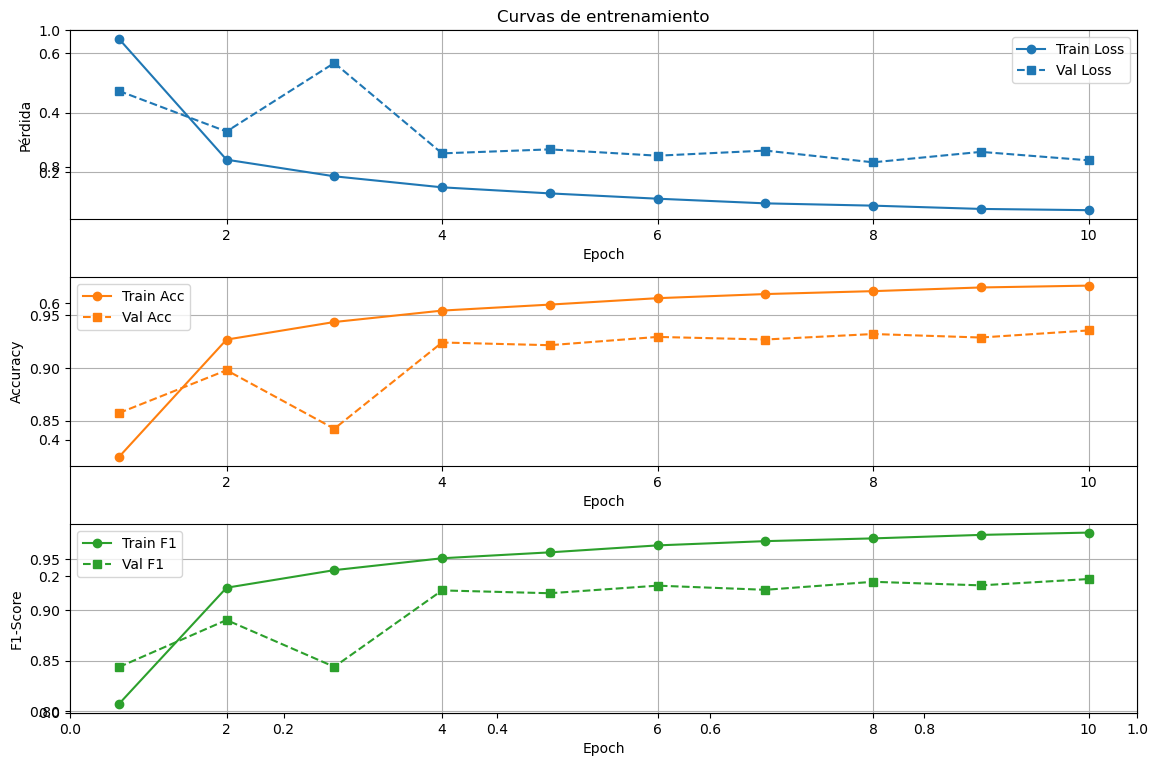

In [5]:
# Evaluación del modelo
# Cargamos desde el disco para poder evaluar en cualquier momento
loaded_pt = torch.load(f"{final_path}/final_model.pt", map_location=DEVICE)
loaded_model = AudioResNetModel(dims=2, num_classes=35).get_model()
loaded_model.load_state_dict(loaded_pt['model_state_dict'])
loaded_model.eval()

plot_curves(loaded_pt, 'Curvas de entrenamiento')

**Análisis del entrenamiento**

Las curvas de training y validación parecen evolucionar de manera conjunta, por lo que no se aprecia de manera clara tendencia al sobreajuste.

In [8]:
# Instanciamos el evaluador y computamos métricas
evaluator = Evaluator(model=loaded_model, device=DEVICE, test_loader=test_loader, preprocessor = preprocessor_test)
confusion_matrix, precission, recall, avg_loss, accuracy, f1, support = evaluator.eval()
print("Pérdida:", avg_loss, "Accuracy:", accuracy, "F1-Score:", f1)

Batches evaluación:   0%|          | 0/48 [00:00<?, ?it/s]

Pérdida: 0.5995513344335998 Accuracy: 0.92005292005292 F1-Score: 0.9164976534608045


Mejora la línea de base

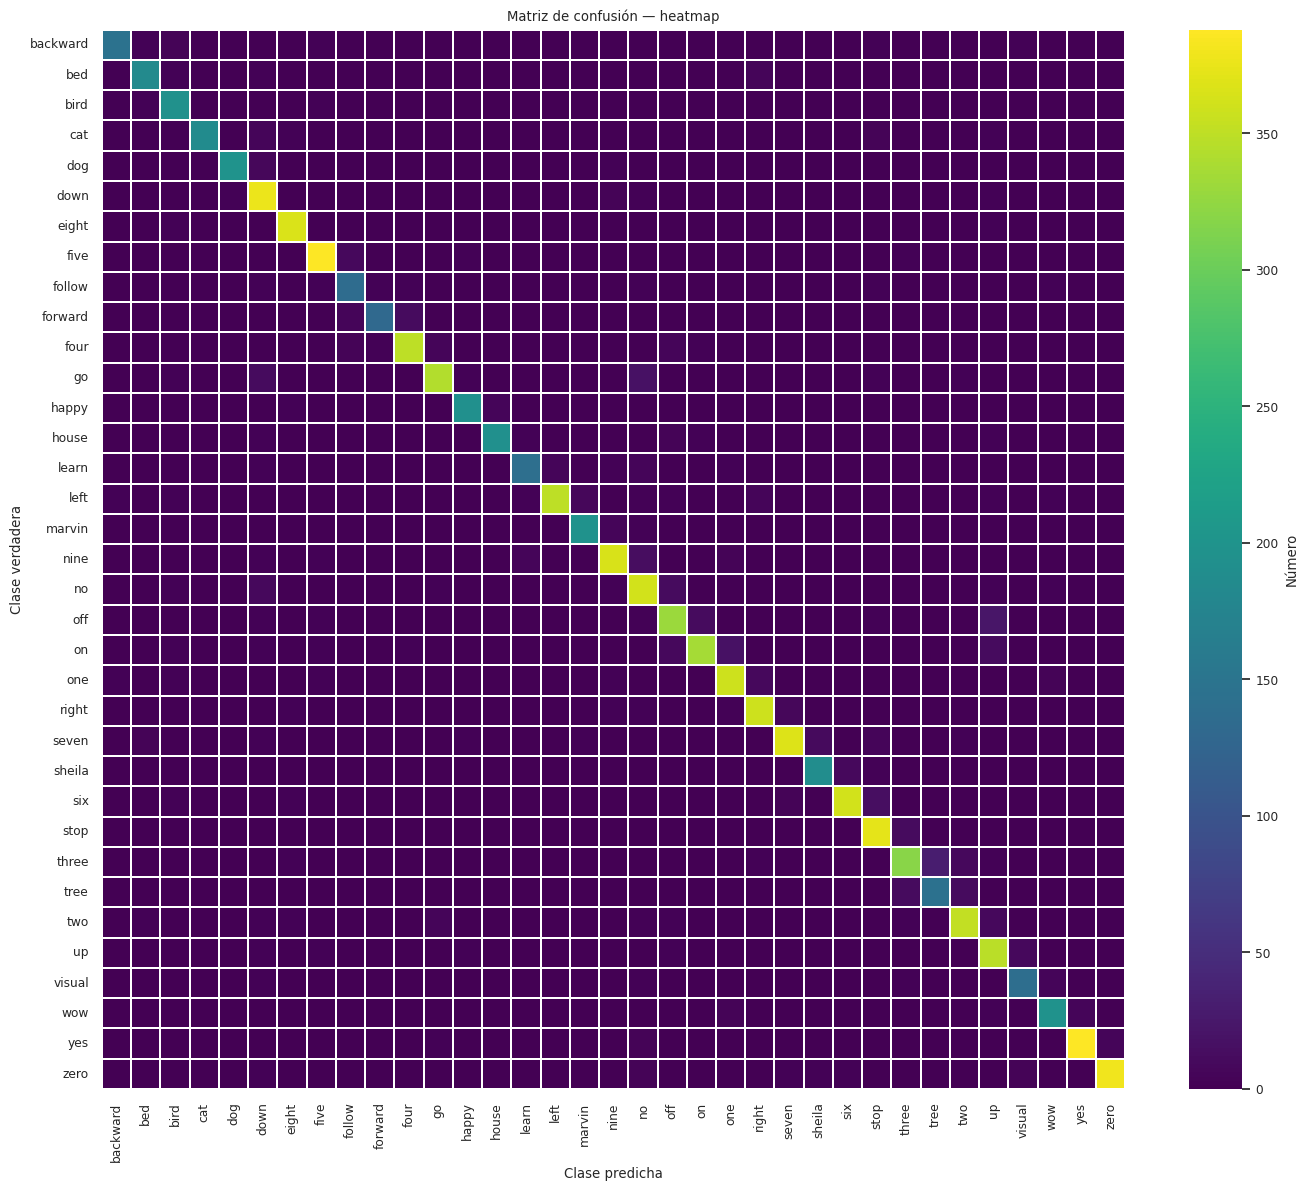

In [9]:
import matplotlib.pyplot as plt
import seaborn as sb

plt.figure(figsize = (14,12))
sb.set(font_scale = 0.8)
ax = sb.heatmap(confusion_matrix,
                annot=False,
                fmt = ".2f",
                cmap = "viridis",
                cbar_kws = {"label": "Número"},
                xticklabels = label_names,
                yticklabels = label_names,
                linewidths = 0.3,
                linecolor = "white")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.xlabel("Clase predicha")
plt.ylabel("Clase verdadera")
plt.title("Matriz de confusión — heatmap")
plt.tight_layout()
plt.show()
plt.rcdefaults()

No se aprecia ninguna clase especialmente problemática.

In [10]:
print("Accuracy:", accuracy, "Precission:", precission, "Recall:", recall, "Pérdida media:", avg_loss, "F1-score:", f1)

Accuracy: 0.92005292005292 Precission: 0.9193998708018475 Recall: 0.9149837516583724 Pérdida media: 0.5995513344335998 F1-score: 0.9164976534608045


In [11]:
## Signal_grad_cam: Preparamos los datos
reference_samples = ['/mnt/data/GSC/normalized-dataset/go/012c8314_nohash_0.wav',
                    '/mnt/data/GSC/normalized-dataset/off/0227998e_nohash_0.wav',
                    '/mnt/data/GSC/normalized-dataset/left/016e2c6d_nohash_0.wav']
reference_labels = [11,19,15]

reference_dataset = GSC(reference_samples, reference_labels)
reference_loader = DataLoader(reference_dataset, batch_size = 3, shuffle = False, 
                              collate_fn = prepare_batch, num_workers = 4)

reference_targets = [11,19,15]

In [12]:
%%capture
## Generamos los CAMs
target_layers = ['layer4.1.conv2', 'layer4.0.conv2', 
                 'layer3.1.conv2', 'layer3.0.conv2', 
                 'layer2.1.conv2', 'layer1.1.conv2']

explainer = "Grad-CAM"

signal_grad_cam_overlays2d(model=loaded_model, dataloader=reference_loader, preprocessor=preprocessor_test,
                          xai_path=xai_path, label_names=label_names, explainer=explainer,
                          target_layers=target_layers, target_classes=reference_labels, 
                          targets_list=reference_targets)

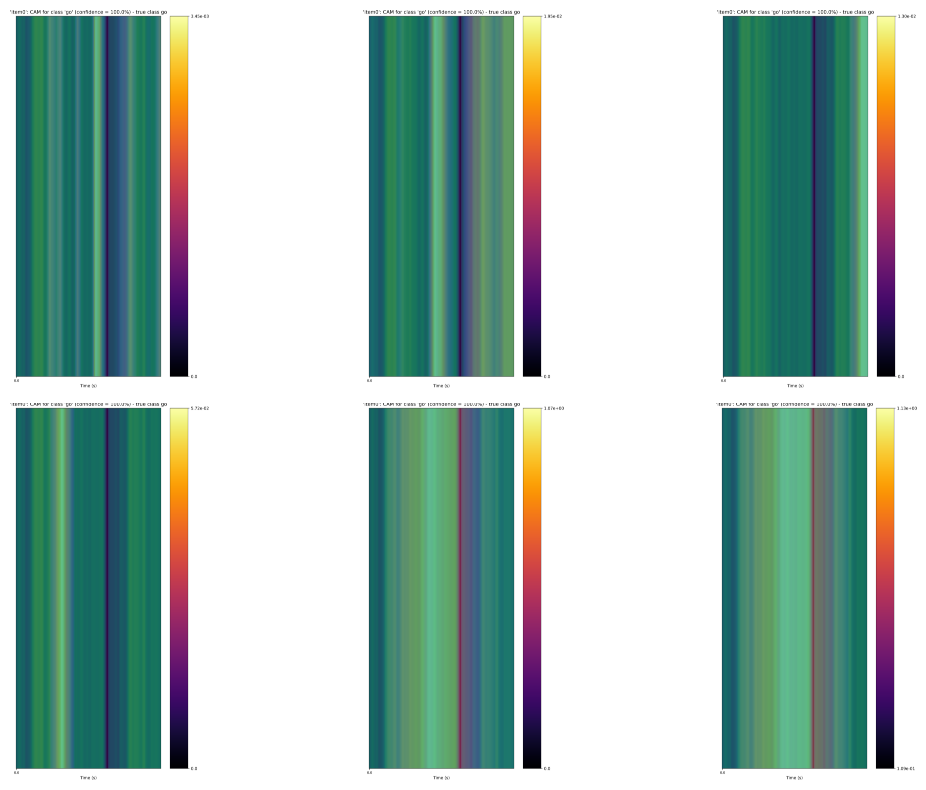

In [13]:
## Visualizamos muestra de capas
# "GO"
images_to_show = sorted(Path(f"{xai_path}/CAMs/overlays/0-2/item0/").glob("*Grad*.png"))
show_image_grid(images_to_show)

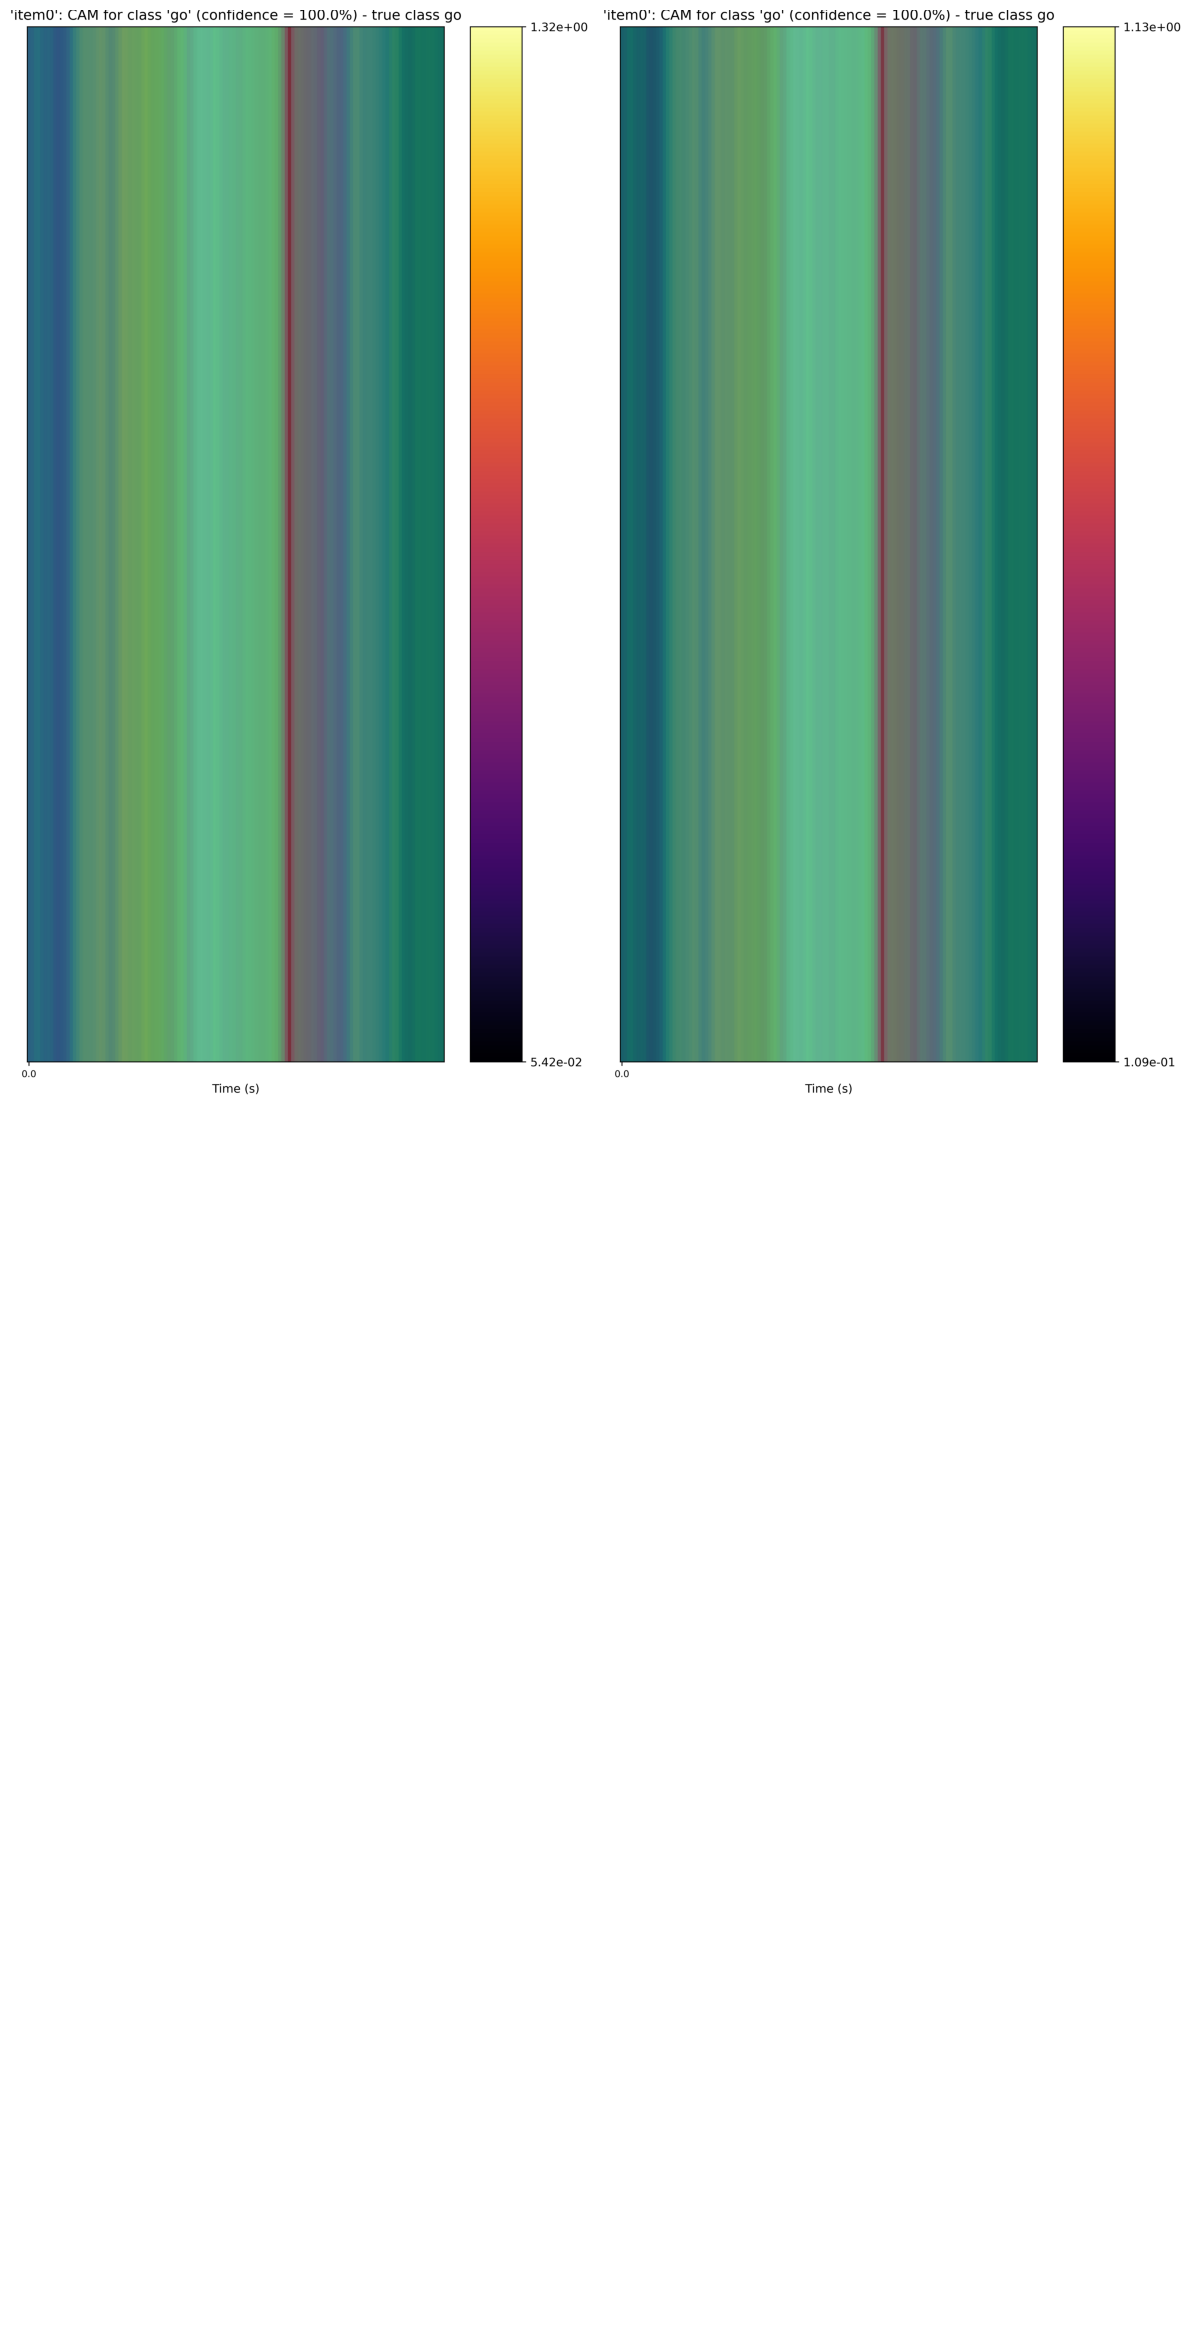

In [6]:
# CAM "GO"
cam_baseline = next(Path(f"/mnt/data/GSC/XAI/00-baseline_resnet18_02/CAMs/overlays/0-2/item0/").glob("*layer4_1_conv2*.png"), None)
cam_exp = next(Path(f"{xai_path}/CAMs/overlays/0-2/item0/").glob("*layer4_1_conv2*.png"), None)

images_to_show = [cam_baseline, cam_exp]
show_image_grid(images_to_show, cols=2, figsize=(12,24))

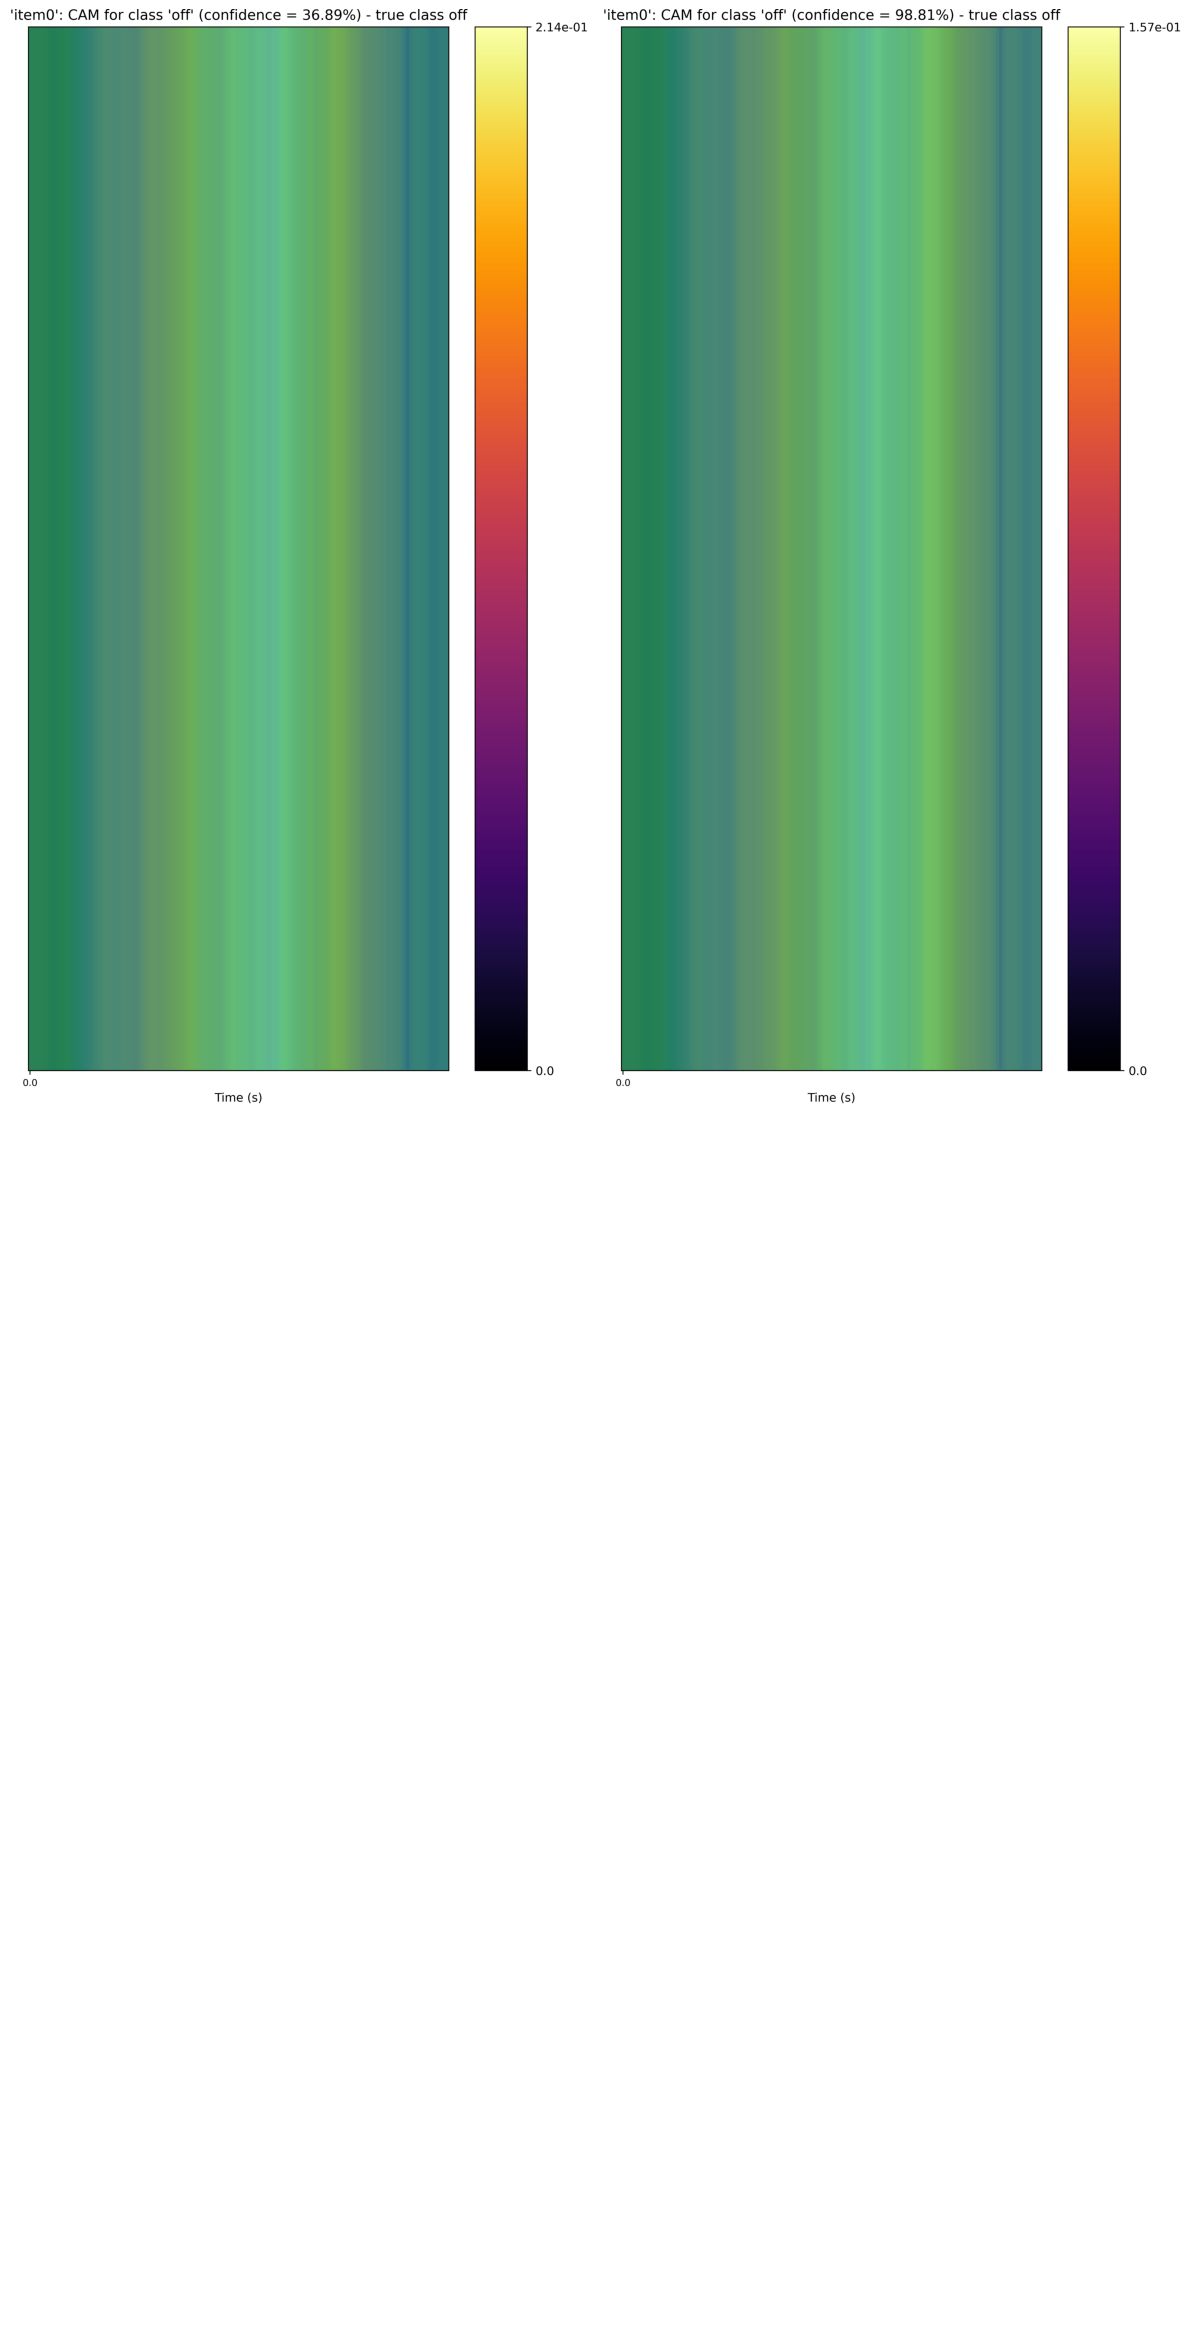

In [7]:
# CAM "OFF"
cam_baseline = next(Path(f"/mnt/data/GSC/XAI/00-baseline_resnet18_02/CAMs/overlays/0-2/item1/").glob("*layer4_1_conv2*.png"), None)
cam_exp = next(Path(f"{xai_path}/CAMs/overlays/0-2/item1/").glob("*layer4_1_conv2*.png"), None)

images_to_show = [cam_baseline, cam_exp]
show_image_grid(images_to_show, cols=2, figsize=(12,24))

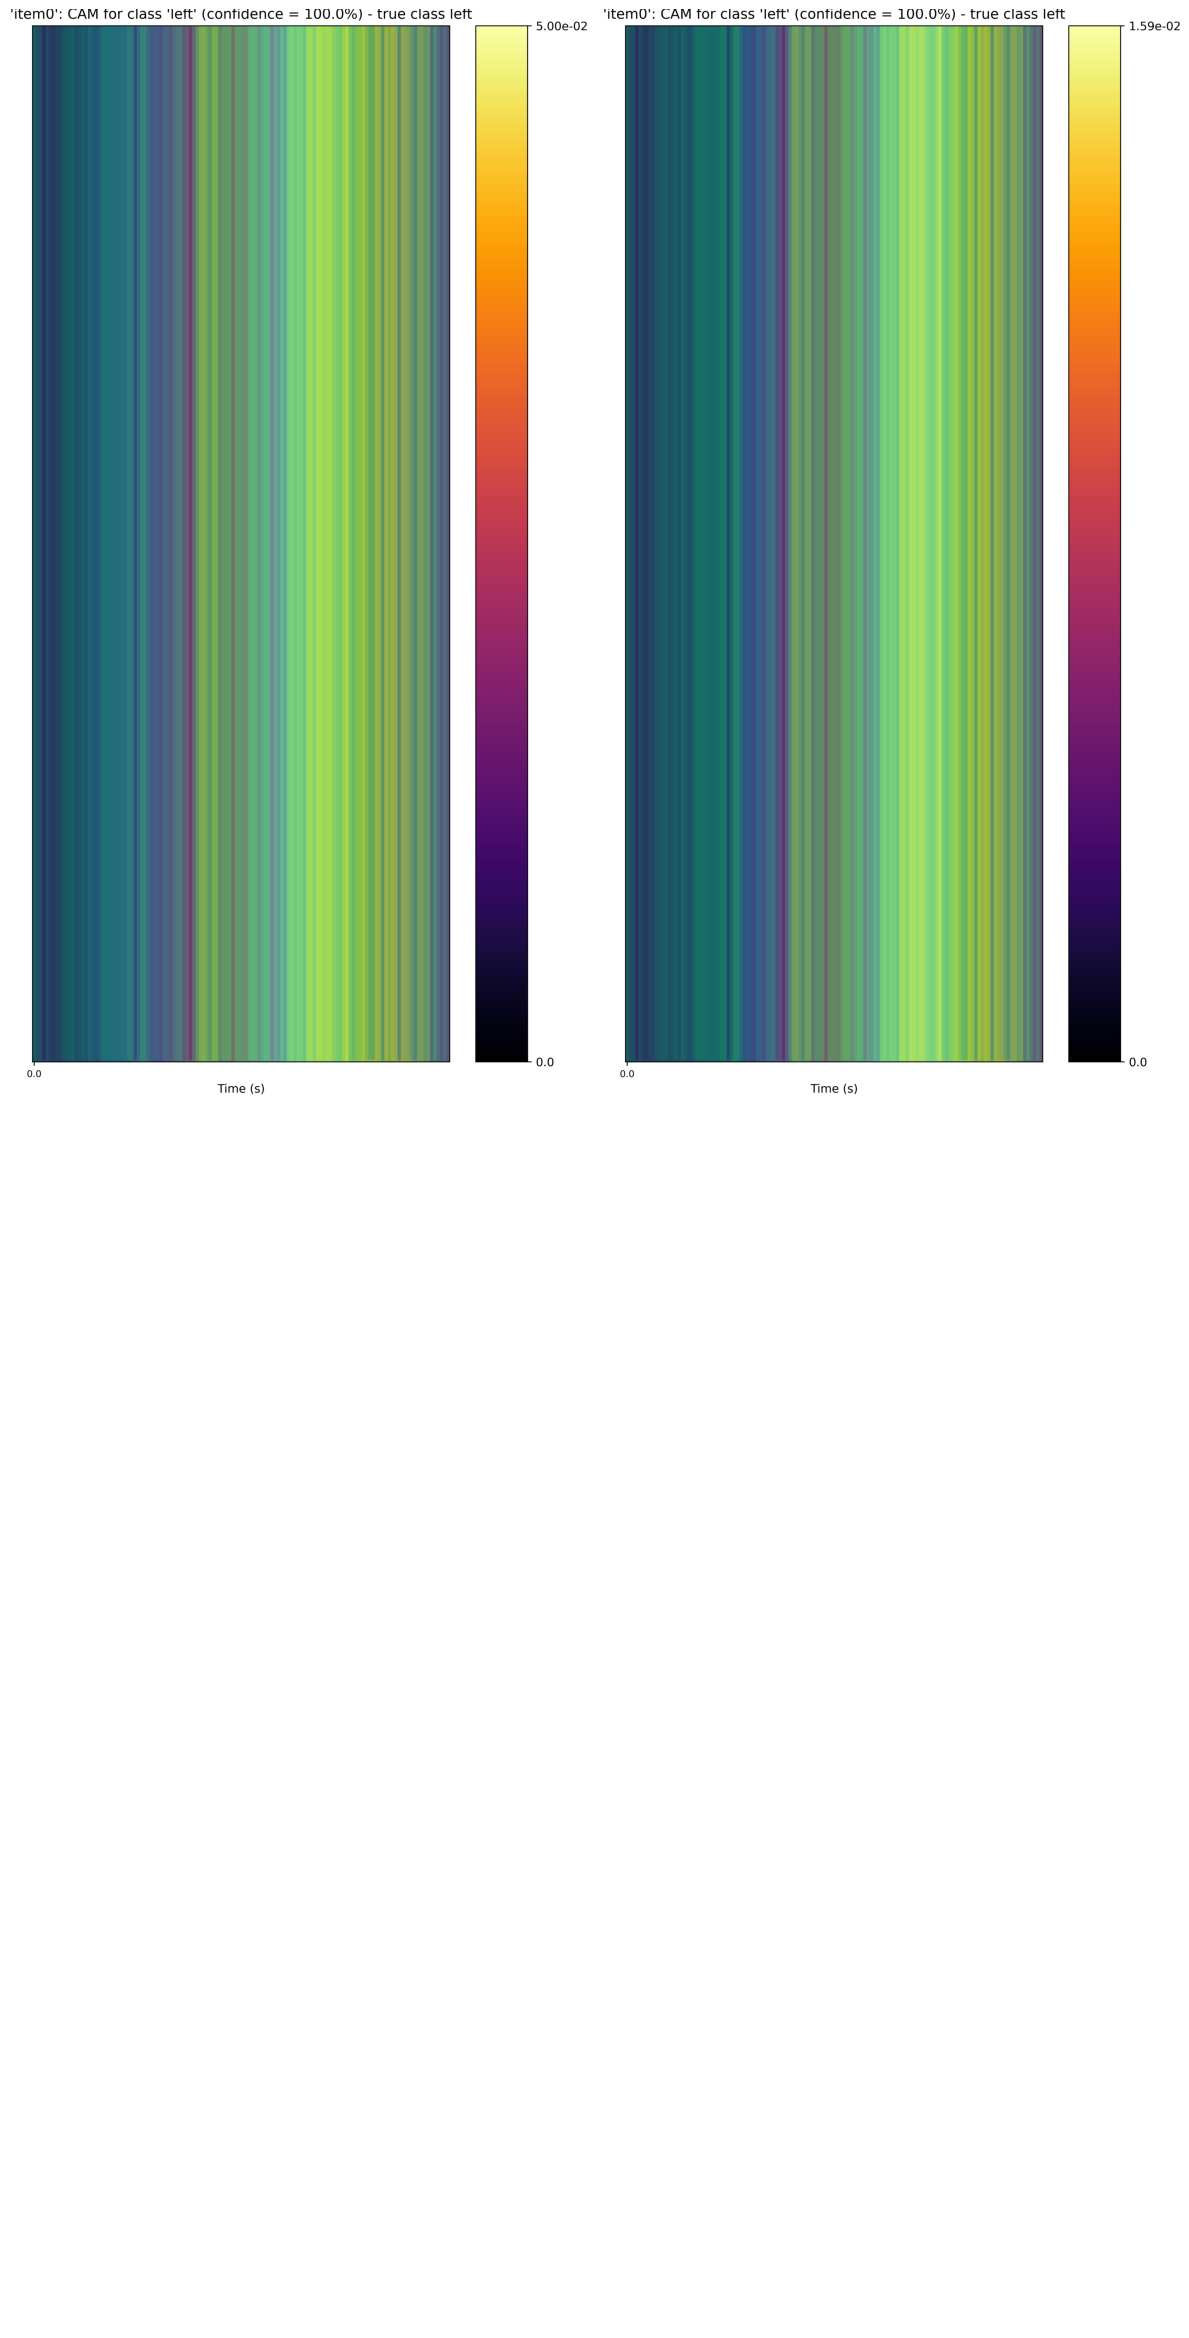

In [8]:
# CAM "LEFT"
cam_baseline = next(Path(f"/mnt/data/GSC/XAI/00-baseline_resnet18_02/CAMs/overlays/0-2/item2/").glob("*layer4_1_conv2*.png"), None)
cam_exp = next(Path(f"{xai_path}/CAMs/overlays/0-2/item2/").glob("*layer4_1_conv2*.png"), None)

images_to_show = [cam_baseline, cam_exp]
show_image_grid(images_to_show, cols=2, figsize=(12,24))

El modelo se adapta bien a estas dimensiones y las métricas son mejores. Se aprecia en los CAMs una mayor confianza en la clasificación positiva y una atención del modelo consistente con la medida de referencia. Aumenta la confianza de manera evidente en la clasificación correcta del monosílabo OFF.

Finalmente, vamos a estimar el coste de entrenamiento a partir del tiempo medio por epoch.

In [6]:
loaded_pt = torch.load(f"{final_path}/final_model.pt", map_location=DEVICE)
etimes = loaded_pt['history'].get('epoch_time')
avg_etime = sum(etimes)/len(etimes)
baseline_etime = 155.78
print(avg_etime)
print("El coste en tiempo por epoch es de", f"{avg_etime/baseline_etime:.2f}", "veces el de la línea de base (v2).")     

158.75416653156282
El coste en tiempo por epoch es de 1.02 veces el de la línea de base (v2).
